### Assignment #3

### Nuclear Physics II

### Instructor: Prof. Sean Dobbs

### April 17th, 2026

*Due by 11 PM, April 24th*

## Guidelines

You will be asked to solve several problems, some of which will be short answers or derivations, some of which will be computational.  For the computational problems, please submit both the answers to the questions and the code that you used to generate these answers.  While any sample code provided will be in python, you can submit programs in any programming language you like, provided that I can compile and run the programs.  You are **strongly** encouraged to use python.  Any figures should be properly labeled, with descriptive axis labels, and either a legend, or a caption describing the contents. You can also use any commonly used HENP packages such as ROOT, as long as I can access them.  If you have any uncertainty on these topics, please ask.


You will be evaluated based on the files contained in your remote GitHub repository at the due date.  You should and commit all the files you created to your local repository on a regular basis. You should do this by adding any new or modified files using "git add", and then finalizing changes using "git commit".  Remember that "git status" will give you information on which files in your repository. have been changed.  Remember to add short, but useful comments when performing a commit. When you are finished with the exercise, push the current status of your local repository to the remote repository on GitHub using the command "git push -u". You are encouraged to push your local files to the remote repository periodically before you are done, and certainly well before the deadline, if possible.

Please also remember to cite code copied from the book or internet, and note if you worked closely with another student.  Citations matter and are good practice!  Please do not use ChatGPT or other generative AI.

## 1. Probability Exercises

1.	A Posisson distribution has a mean of 3.7.  Calculate “by hand” the probability it will give two events or less, and show your work.  Then calculate the same result using poisson_cdf in ROOT, or the equivalent in your favorite math program, and compare the two results.

## Answer for 1.1

The probability of finding a number of iterations equal to or less than a desired result is given by $f(n,v)=\sum_{i=0}^{n}\frac{v^i e^{-v}}{i!}$ for n = 3.7 and v = 2 is $f(3.7, 2) = 0.29.$ Using the Python package scipy.stats, the following line is run:

poisson.cdf(n,v)

returning a value of 0.29. These are similar, likely because cdf uses the same method for determining the likelihood of an event rate.

2. During a meteor shower, meteors fall at the rate of 15.7 per hour. What is the probability of observing less than 5 in a given period of 30 minutes, using the fact that this probability is described by the Poisson distribution?  What is the probability if instead you use the Gaussian approximation to the Poisson?

## Answer for 1.2

Using the same function as above, the likelihood is 0.09. Using a Gaussian approximation, the probability is 0.03.

3. Numerically calculate the following for a Gaussian distribution.  You can use whatever tools you would like to calculate this, but you should include the code used to do the calculations, or include screenshots if you are using a web-based tool.  Note that ROOT has definitions of the Gaussian and other useful functions, and that python has several useful functions in `scipy.stats.norm`. Note that some questions ask for probabilities symmetric around the mean, and some do not (so-called "one tailed probabilities").

(a) What is the probability of a value lying more than 1.23σ from the mean? 

(b) What is the probability of a value lying more than 2.43σ above the mean? 

(c) What is the probability that a value lies more than 0.5σ but less than 1.5σ from the mean? 

(d) What is the probability that a value lies above 1.2σ on the low side of the mean, and below 2.1σ on the high side? 

(e) Within how many standard deviations does the probability of a value occurring equal 50%? 

(f) How many standard deviations correspond to a one-tailed probability of 99%?


## Answer for 1.3

The code used to calculate these values is provided below.

a. 0.22

b. 0.0075

c. 0.48

d. 0.87

e. 0

f. 2.91

In [ ]:
#Problem 3
#Part (a)
import scipy.stats as scs.norm
import numpy as np

mean = 5
sigma = (5 * 0.68)
left_tail = scs.norm.cdf(mean - sigma * 1.23, loc=mean, scale=sigma)
right_tail = scs.norm.sf(mean + sigma * 1.23, loc=mean, scale=sigma)
print(left_tail + right_tail)
#print(1-gaussian_approx)

#Part (b)
#mean = 5
#sigma = (mean * 0.68)
right_distribution = scs.norm.sf(mean + sigma * 2.43, loc=mean, scale=sigma)
print(right_distribution)

#Part (c)
between_dis_up = scs.norm.cdf(mean + (sigma * 1.5), loc=mean, scale=sigma) - sc>
between_dis_low = - scs.norm.cdf(mean - (sigma * 1.5), loc=mean, scale=sigma) +>
print(between_dis_up + between_dis_low)

#Part (d)
above = scs.norm.cdf(mean + (sigma * 2.1), loc=mean, scale=sigma) - scs.norm.cd>
print(above)

#Part (e)
std = scs.norm.ppf(.5)
print(std)

#Part (f)
std = scs.norm.ppdf(.99)
print(std)

## 2. Significance Estimation

2.	In 1992, the ARGUS e+e− annihilation experiment reported the observation of the charmed and doubly strange baryon &Omega;<sub>c</sub> through its decay channel  &Xi;<sup>-</sup>K<sup>-</sup>&pi;<sup>+</sup>&pi;<sup>+</sup>  The mass spectrum seen by the experiment is shown below. Let’s try to estimate the significance of this signal.

<img src="./argus_omega_c.png" alt="Distribution of XiKpipi mass from ARGUS" width="500px">

Under the assumption that the background is constant in the M = 2.4 – 3.0 GeV region:

1. Estimate the average number of background events per mass bin.
2.	Define a $\pm2\sigma$ mass window around the peak
3.	Count the total number of candidates N(obs) in the $\pm2\sigma$ region around the peak.
4.	Estimate the total number of expected background events $\mu_b$ in this region.
5.	Estimate the probability for the Poisson distribution to fluctuate from $\mu_b$ to N(obs) or larger.
6.	Taking this probability as a p-value, calculate the equivalent significance level for this signal.

## Answer for 2

1. Taking all events not part of the signal divided by the total number of bins, the estimated average background event per bin is 0.65.

## 3. Exponential Fits

A set of 40 radioactive decays were observed at various times $t$, in units of seconds, given by the following list: <code>{4.99, 4.87, 2.59, 3.04, 3.39, 6.20, l0.61, 7.64, 3.92, 5.33, 4.85, 2.39, 4.l6, 6.74, 3.53, 5.86, 5.4l, 26.25, 4.40, l0.79, 7.08, 2.86, 33.92, 3.03, 0.98, 5.63, 4.89, 2.26, l0.49, 6.5l, 7.36, 2.l3, 6.45, 2.29, 2l.l5, 4.07, 4.34, 5.38, 7.69, 4.93}.</code> 

(a) Assuming an exponential decay, that is $N(t) \propto exp(–t / \tau)$, obtain the lifetime $\tau$ and its error using the maximum-likelihood method. Is the hypothesis of an exponential decay compatible with the data? 

(b) The data can be grouped into the following bins: 21 decays from 0 to 5 seconds, 13 decays from 5 to 10 seconds, and 3 decays from 10 to 15 seconds. Determine the decay constant λ and its error using the least-squares method. Compare this result to that from part (a).


Below are some simple fitting examples in python, but feel free to use whatever fitting package you want.

In [ ]:
# if needed
#import sys
#!{sys.executable} -m pip install --upgrade scipy
#!{sys.executable} -m pip install --upgrade numba
#!{sys.executable} -m pip install --upgrade iminuit

In [ ]:
#from random import random,uniform
import matplotlib.pyplot as plt
import numpy as np
import math
import scipy
from iminuit import Minuit
#from iminuit.cost import Cost
from iminuit.cost import UnbinnedNLL, ExtendedUnbinnedNLL, ExtendedBinnedNLL, LeastSquares
from scipy.stats import truncnorm, truncexpon, norm, expon

#print(scipy.__version__)

xrange = (5,15)
def f( x, N, mean, sigma ):
    # normalized Gaussian
    return N*norm.pdf(x, mean, sigma)


### test data
test_data = np.random.normal(10,2,400)

### Examples of fits using iminuit.  Note that it has a lot more cool features!
### https://scikit-hep.org/iminuit/tutorials.html
### https://indico.cern.ch/event/833895/contributions/3577808/attachments/1927550/3191336/iminuit_intro.html

## actual data
data[40] = {4.99, 4.87, 2.59, 3.04, 3.39, 6.20, 10.61, 7.64, 3.92, 5.33, 4.85, 2.39, 4.16, 6.74, 
3.53, 5.86, 5.41, 26.25, 4.40, 10.79, 7.08, 2.86, 33.92, 3.03, 0.98, 5.63, 4.89, 2.26, 10.49, 
6.51, 7.36, 2.13, 6.45, 2.29, 21.l5, 4.07, 4.34, 5.38, 7.69, 4.93}

### Minuit least squares fit
binned_hist, bins = np.histogram(data, bins=20, range=xrange)
bin_centers = bins[:-1] + np.diff(bins) / 2
data_yerr = [np.sqrt(x) for x in binned_hist]

least_squares = LeastSquares(bin_centers, binned_hist, data_yerr, f)

m = Minuit(least_squares, N=100, mean=10, sigma=1)  # starting values for parameters

m.migrad()  # finds minimum of least_squares function
m.hesse()   # accurately computes uncertainties


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 16.99 (χ²/ndof = 1.0)      │              Nfcn = 90               │
│ EDM = 4.21e-06 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬───────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name  │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼───────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N     │    191    │    10     │            │            │         │         │       │
│ 1 │ mean  │   10.0    │    0.1    │            │            │         │         │       │
│ 2 │ sigma │   1.85    │   0.08    │            │            │         │         │       │
└───┴───────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───────┬─────────────────────────┐
│       │       N    mean   sigma │
├───────┼─────────────────────────┤
│     N │    96.2  -0.003   0.035 │
│  mean │  -0.003 0.00958  -0.000 │
│ sigma │   0.035  -0.000  0.0061 │
└───────┴─────────────────────────┘

In [15]:
def pdf( x, mean, sigma ):
    return norm.pdf(x, mean, sigma)

nll = UnbinnedNLL(test_data, pdf)

#print(test_data)

mlm = Minuit(nll, mean=10, sigma=1)  # starting values for parameters
mlm.limits["mean"] = (0, 20)
mlm.limits["sigma"] = (0, 10)

mlm.migrad()  # finds minimum of least_squares function
mlm.hesse()   # accurately computes uncertainties


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1645                       │              Nfcn = 56               │
│ EDM = 1.86e-06 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬───────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name  │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼───────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ mean  │   9.96    │   0.09    │            │            │    0    │   20    │       │
│ 1 │ sigma │   1.89    │   0.07    │            │            │    0    │   10    │       │
└───┴───────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───────┬─────────────────┐
│       │    mean   sigma │
├───────┼─────────────────┤
│  mean │ 0.00895   0.000 │
│ sigma │   0.000 0.00447 │
└───────┴─────────────────┘

mean = 10.032 +- 0.117
sigma = 1.910 +- 0.118


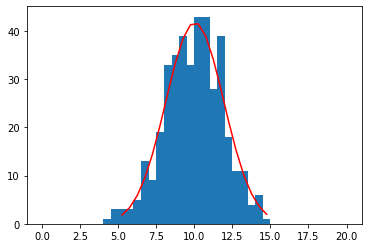

In [16]:
### python built-in least squares fit for comparison
params, cov = scipy.optimize.curve_fit(f, bin_centers, binned_hist)
print('mean = %5.3f +- %5.3f'%(params[1],np.sqrt(cov[1][1])))
print('sigma = %5.3f +- %5.3f'%(params[2],np.sqrt(cov[2][2])))

plt.hist(test_data, bins=40, range=(0,20))
plt.plot(bin_centers, f(bin_centers,*params), 'r-')
plt.show()

## 4. Bootstrapping Uncertainties

An experiment uses two production lines for building detector sensors (for example for a silicon strip detector). A test series of ten sensors is delivered from each production line. The average detection inefficiencies of the ten sensors are found to be as follows: first production line: <code>9, 12, 11, 8, 7, 5, 8, 9, 10, 7%</code>; second production line: <code>8, 13, 4, 7, 7, 8, 6, 9, 10, 5%.</code>
    
(a) Determine the sample mean and estimate its variance. 

(b) Resample the data, that is draw ten values (with replacement) to obtain a first bootstrap sample and determine its sample mean. Repeat the resampling 100 times and obtain an empirical bootstrap distribution of the sample mean. Show a histogram of the bootstrapped means. Determine 68% and 95% CL bootstrap intervals, using the simple percentile intervals. Is there any hint towards a different inefficiency performance for the sensors from the two production lines?

## Solution to 4(a)

(a) The first production line is 8.6% and the second line is 7.2%. Total mean is 7.9%. Sample variance is given by 

$\sigma^2 = \sum_{i=0}^{N}\frac{(x_i-\mu)^2}{N}$. 

Using this equation, the variance is 4.3 and 6.7 respectively.

(b) From plotting the two distributions, there seems to be a wider variance in the second production line even though the average error is smaller than the first production line. 

In [ ]:
import numpy as np
import scipy
import matplotlib.pyplot as plt

x = np.linspace(0,20,100)
average = []
otheraverage = []
firstmean = 8.6
secondmean = 7.7

firstvar = 4.3
secondvar = 6.7

for i in range(100):
  #y = np.random.default_rng().random(10)
  mean = np.random.normal(loc=firstmean, scale=firstvar, size=10)
  mean2 = np.random.normal(loc=secondmean, scale=secondvar, size=10)
  sample_mean = np.mean(mean)
  sample_mean2 = np.mean(mean2)
  if sample_mean < 0:
    sample_mean = 0
  if sample_mean2 < 0:
    sample_mean2 = 0
  average.append(sample_mean)
  otheraverage.append(sample_mean2)

var = np.sqrt(np.var(average))
bootstrap_first_av = np.mean(average)
othervar = np.sqrt(np.var(otheraverage))
bootstrap_second_av = np.mean(otheraverage)
plt.hist(average, x, label="first distribution")
#plt.show()
plt.xlabel("Sampled Mean Value")
plt.ylabel("Counts")

plt.axvline(bootstrap_first_av - var, color='blue', linestyle='dashed',linewidth=2)
plt.axvline(var + bootstrap_first_av, color='blue', linestyle='dashed',linewidth=2)
plt.axvline(bootstrap_first_av - 2*var, color='blue', linestyle='dashed',linewidth=2)
plt.axvline(2*var + bootstrap_first_av, color='blue', linestyle='dashed',linewidth=2)


plt.axvline(bootstrap_second_av - othervar, color='orange', linestyle='dashed')
plt.axvline(othervar + bootstrap_second_av, color='orange', linestyle='dashed')
plt.axvline(bootstrap_second_av - 2*othervar, color='orange', linestyle='dashed')
plt.axvline(2*othervar + bootstrap_second_av, color='orange', linestyle='dashed')

plt.axvline(bootstrap_first_av, color='blue', linestyle='dashed',linewidth=2)
plt.axvline(bootstrap_second_av, color='orange', linestyle='dashed',linewidth=2)

plt.hist(otheraverage, x, label="second distribution")
plt.legend(loc='upper left')
plt.show()